In [1]:
from anomaly_detection.utils.scoring import QuantileScorer
import numpy as np
import matplotlib.pyplot as plt
import torch

In [7]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import minmax_scale_per_sample
full_dataset = load_dataset("FJ")
full_dataset = minmax_scale_per_sample(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch


<BarContainer object of 96 artists>

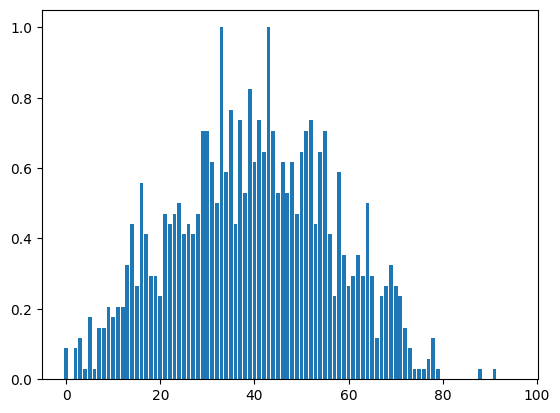

In [9]:
plt.bar(range(96), full_dataset[46])

<BarContainer object of 96 artists>

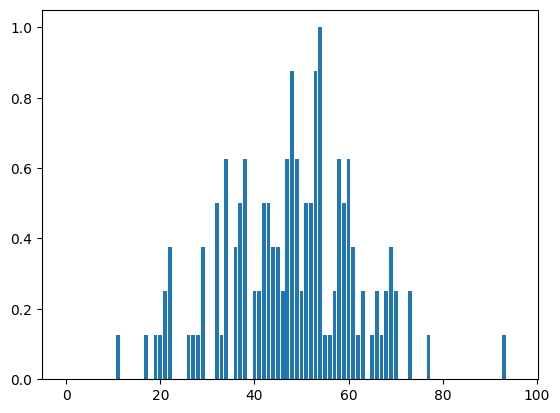

In [10]:
plt.bar(range(96), full_dataset[244])

mean: 0.66176474
i: 91.2


C:\Users\hrdyj\AppData\Local\Temp\ipykernel_29840\2703134577.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  residual = np.abs(full_dataset[244] - full_dataset[46])


<BarContainer object of 96 artists>

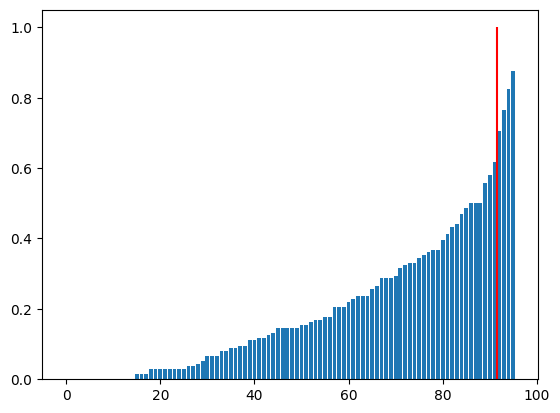

In [36]:
residual = np.abs(full_dataset[244] - full_dataset[46])
residual = sorted(residual)
q = 0.96
i = q * (96-1)

i_up = np.ceil(i)
i_down = np.floor(i)
print('mean:', np.mean((residual[int(i_up)], residual[int(i_down)])))

print("i:", i)
plt.vlines(np.mean((i_up, i_down)), ymin=0, ymax=1, zorder=2, color='red')
plt.bar(range(96), residual, zorder=0)

In [35]:
scorer = QuantileScorer(q=q)
scorer.score(full_dataset[244], full_dataset[46])

tensor(0.1471)

In [40]:
from anomaly_detection.config.paths import CHECKPOINT_DIR
from anomaly_detection.models.conv_ae_v3_1 import AE_v3
import os

checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, "AE_conv_v3.1_Wass_Reg_train_date=01-03_10-20", "ae_conv_v3.1_Wass_Reg_ep246.pth"), map_location="cpu")

config = checkpoint["config"]

model = AE_v3()
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

AE_v3(
  (encoder): Sequential(
    (0): Conv1d(1, 2, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(2, 4, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(4, 8, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv1d(8, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (10): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): Sigmoid()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(32, 16, kernel_size=(3,), stride=(1,), padding

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


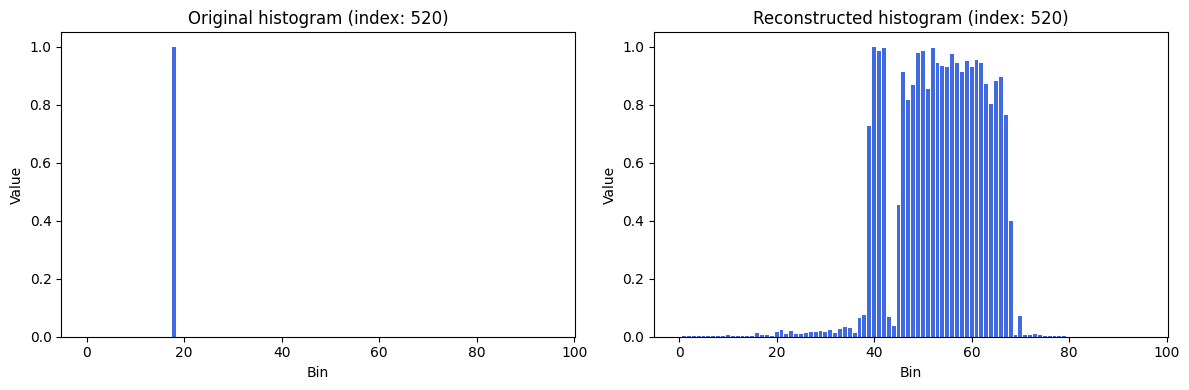

In [41]:
import torch.nn as nn
device = 'cpu'
model.eval()
idx = 520

with torch.no_grad():
    x = full_dataset[idx].to(device)
    pred = model(x.reshape(1,1,96))

    criterion = nn.MSELoss()
    loss = criterion(pred, x).item()

original = x.squeeze().cpu().numpy()
reconstructed = pred.squeeze().cpu().numpy()

_, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(original)), original, zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Value")

axes[1].bar(range(len(reconstructed)), reconstructed, zorder=1, color='royalblue')
axes[1].set_title(f"Reconstructed histogram (index: {idx})")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

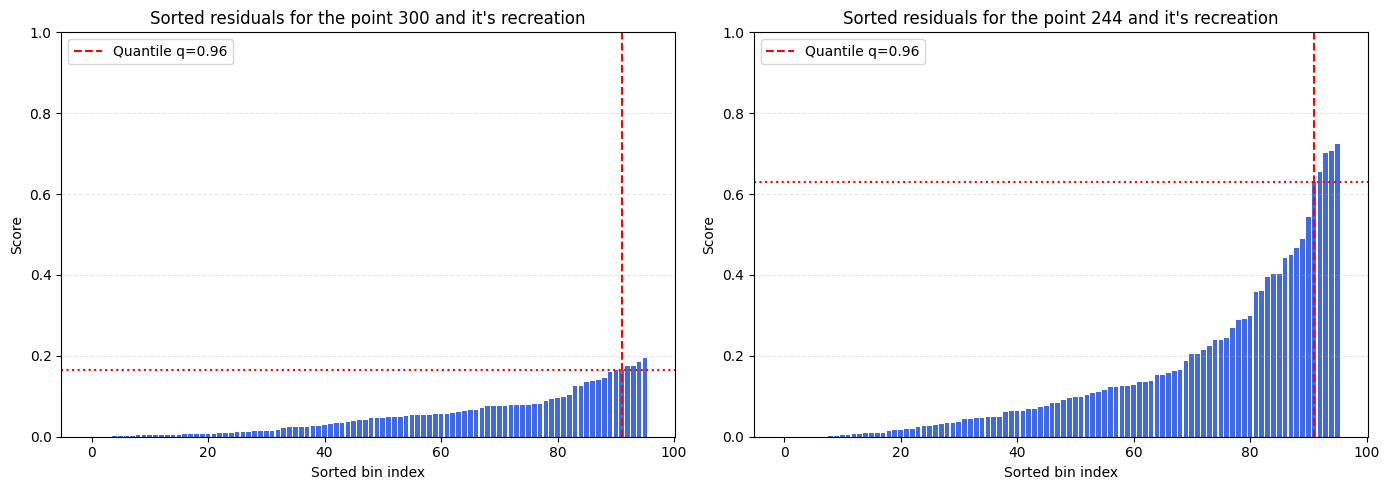

In [74]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_residual_slope(idx, title, color_bar, q=0.96):
    # 1. Získanie dát a rekonštrukcia
    original = full_dataset[idx]
    
    with torch.no_grad():
        # Úprava na (1, 1, 96) pre CNN modely
        reconstruction = model(original.reshape(1, 1, 96)).squeeze()
    
    # 2. Výpočet rezíduí a zoradenie
    residual_raw = torch.abs(original - reconstruction).cpu().numpy()
    residual_sorted = np.sort(residual_raw)
    
    # 3. Výpočet kvantilu
    n_bins = len(residual_sorted)
    idx_q = int(q * (n_bins - 1))
    threshold_val = residual_sorted[idx_q]
    
    # 4. Vykresľovanie
    plt.bar(range(n_bins), residual_sorted, color='royalblue')
    plt.axvline(idx_q, color='red', linestyle='--', label=f'Quantile q={q}')
    plt.axhline(threshold_val, color='red', linestyle=':')
    
    # NASTAVENIE OSI: Fixné rozpätie 0 až 1
    plt.ylim(0, 1.0) 
    
    plt.title(title)
    plt.xlabel("Sorted bin index")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.3)

# --- Vytvorenie porovnania ---
plt.figure(figsize=(14, 5))

# Graf 1: Normálne dáta
plt.subplot(1, 2, 1)
plot_residual_slope(idx=300, title="Sorted residuals for the point 300 and it's recreation", color_bar="skyblue")

# Graf 2: Anomália
plt.subplot(1, 2, 2)
plot_residual_slope(idx=244, title="Sorted residuals for the point 244 and it's recreation", color_bar="orange")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_histograms(hist1, hist2, hist3):
    fig, axes = plt.subplots(1, 3)
    
    axes[0].bar(range(len(hist1)), hist1)
    axes[1].bar(range(len(hist2)), hist2)
    axes[2].bar(range(len(hist3)), hist3)
    
    plt.show()

si_data = load_dataset("SI")
pa_data = load_dataset("PA")
plot_histograms(full_dataset[0], si_data[0], pa_data[0])

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\SI\SI01U1\SI01U1_ch
Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\MWPC\PA01U1\PA01U1_ch


In [83]:
full_dataset = load_dataset("FJ")

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch


In [92]:
len(si_data[0])

1280

<BarContainer object of 768 artists>

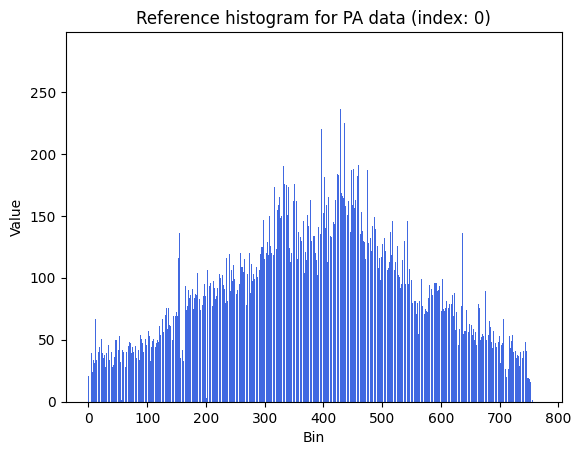

In [90]:
plt.title("Reference histogram for PA data (index: 0)")
plt.xlabel("Bin")
plt.ylabel("Value")
plt.bar(range(len(pa_data[0])), pa_data[0], color='royalblue')